<a href="https://colab.research.google.com/github/rudalshan0412-code/Building-an-Artificial-Neural-Network-from-Scratch-using-NumPy/blob/main/%EB%AF%B8%EB%8B%88_%EB%87%8C_%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B802(%EC%88%AB%EC%9E%90_%EA%B5%AC%EB%B6%84).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist # mnist 데이터(숫자 이미지 데이터)를 가져온다
import matplotlib.pyplot as plt # 불러온 데이터를 확인하기 위한 패키지

In [ ]:
#mnist 데이터 불러오기
#mnist 데이터는 손으로 쓴 0부터 9까지의 숫자 이미지 데이터이다


(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape) # x는 이미지 데이터이고
print(y_train.shape) # y는 이미지 데이터의 실제 값이 무엇인지 알려주는 정답 데이터다
print(x_test.shape) # x_train[1] 은 이미지, y_train[1] 은 첫번째 이미지가 어떤 숫자인지 형태이다
print(y_test.shape) # 따라서, 데이터의 순서를 바꾸면 이미지와 정답(label)이 틀려진다

# (60000, 28, 28)
# (60000,)
# (10000, 28, 28)
# (10000,)
# 학습하는 이미지는 60,000장, 테스트 하는 이미지는 10,000장이다.
# 이미지의 크기는 28 X 28이다. 이때 단위는 픽셀이다

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


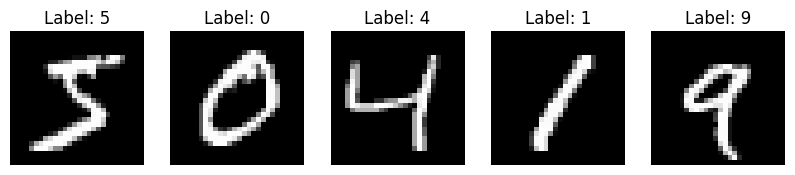

In [ ]:
# 불러온 데이터 확인하기

#이미지 확인하기 (처음 5장)
plt.figure(figsize=(10, 3)) # 전체 가로, 세로 크기 설정

for i in range(5):
    plt.subplot(1, 5, i + 1) # 1행 5열 중 i+1번째 칸
    plt.imshow(x_train[i], cmap='gray') # 흑백(gray)으로 출력
    plt.title(f"Label: {y_train[i]}") # 실제 정답(레이블) 표시
    plt.axis('off') # 격자선 숨기기

plt.show()

In [ ]:
# 이미지 데이터를 신경망에 넣어주기 위해 형태를 바꾼다
# 이미지를 28 X 28로 나눠서 각 픽셀마다의 예측값을 받는다

x_train = x_train.reshape(60000, 784)
# 데이터를 784조각(28*28)으로 나누어 한 줄로 세운다.
# 이때, 28X28과 784는 2차원인지 1차원인지의 차이가 있다(28*28은 2차원, 784는 1차원).

x_test = x_test.reshape(10000, 784)

# 정규화
x_train = x_train / 255.0
x_test = x_test / 255.0
# 픽셀값은 0~255이기에 255로 나누어준다
# 정규화는 값을 0~1 사이로 만들어 값이 너무 비대칭적이거나 가파르지 않게 만든다
# 활성화 함수의 경우에도 값이 조금만 커져도(5정도만 넣어도 해당한다) 출력값이 1에 수렴하게 되기에(기울기 소실) 정규화가 중요하다


#print(x_train.shape)
#print(x_train.max())
#print(x_train.min())

In [ ]:
# y(정답 데이터)를 one-hot 형태로 바꾸기
# one-hot 형태는 정답인 원소의 위치만 1로 표기(아닌 위치는 0)하는 형태이다
# y_train[0] = 5 -> [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]

def one_hot(y, num_classes = 10):

  result = np.zeros((len(y), num_classes)) # np.zeros(a, b)는 0으로 이루어진 a행 b열 배열을 만든다
  result[np.arange(len(y)), y] = 1 # 정답에 해당하는 원소만 1로 바꾼다(반복문을 쓴 경우와 결과가 같다)
  return result

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

#print(y_train_onehot[0])
#print(y_test_onehot[1])

In [ ]:
# 가중치와 편향 초기화

input_size = 784 # 입력층의 크기
hidden_size = 128 # 은닉층의 크기
output_size = 10 # 출력층의 크기

# 모델의 구조 784 -> 128 -> 10

np.random.seed(0) # 특정 무작위의 수 고정(한번 생성된 무작위의 수는 변하지 않는다)

w1 = np.random.randn(input_size, hidden_size) * 0.01
# np.random.randn 은 -3.0 ~ 3.0 까지의 무작위의 수를 생성한다
# input_size 만큼의 행과 hidden_size 만큼의 열이 생성된다
# 정규화를 위해 0.01을 곱한다

b1 = np.zeros((1, hidden_size))
w2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

#print(w1, shape)
#print(b1, shape)
#print(w2, shape)
#print(b2, shape)

In [ ]:
# 활성화 함수 만들기

def relu(x):

  return np.maximum(0, x) # 음수는 0으로 반환, 양수는 그대로 반환한다

  # 인간의 뇌는 자극을 보낸다 or 안보낸다만 결정.
  # sigmoid는 값이 극한으로 갈수록 기울기의 크기는 작아진다
  # 0.5 -> 0.9는 기울기의 변화가 있어도 숫자가 엄청나게 커져도 0.9 -> 1.0 가 최대이기에(작아지는 경우도 동일)
  # 이 문제로 인해 sigmoid 미분값이 매우 작아지고, 이는 역전파 과정에서 초반 가중치 계산에 오류가 생긴다
  # 이를 해결하기 위해 sigmoid 대신 relu를 쓴다
  # 음수의 값을 보내면 더 정밀해지는거 아닌지...?(굳이 최소를 0으로 해야하는지)

def relu_derivative(x):

  return (x > 0).astype(float) # 양수면 1, 음수면 0이다
  # relu 값을 미분하면 1이기(y = x 미분) 때문이다

def softmax(x):

  x = x - np.max(x, axis = 1, keepdims = True)
  exp_x = np.exp(x)

  return exp_x / np.sum(exp_x, axis = 1, keepdims = True)

# softmax 함수는 확률의 총합을 1로 바꾸어준다(총합 1에 각각 확률의 비율로 바꾸어줌)

In [ ]:
# loss(손실값) 함수 만들기

def cross_entropy(y_true, y_pred):

  return -np.mean(np.sum(y_true * np.log(y_pred + 1e-7), axis = 1))

  # cross_entrpy()는 손실값을 로그를 씌워 계산한다(오차가 커질수록 반환값이 기하급수적으로 커진다)
  # 1e - 7은 log 0을 막기 위한 매우 작은 값(실제 결괏값에 영향을 최소화하기 위해)

In [ ]:
# 정확도 계산 함수 만들기

def accuracy(y_true, y_pred):

  true_labels = np.argmax(y_true, axis = 1) # np.argmax는 배열 내에서의 제일 큰 값의 위치를 찾아준다(.index(max())랑 같은 역할)
  pred_labels = np.argmax(y_pred, axis = 1)

  return np.mean(true_labels == pred_labels)

In [ ]:
# Forward propagation(순전파) 만들기

def forward(x, w1, b1, w2, b2):

  z1 = x @ w1 + b1 # @ 는 행렬곱이라는 뜻 (여기서는 np.dot랑 같은 뜻이나 3차원 이상의 계산에서부터 역할이 구분된다)
  a1 = relu(z1)
  z2 = a1 @ w2 + b2
  y_pred = softmax(z2)

  return z1, a1, z2, y_pred

In [ ]:
# 예측결과 시각화 함수def plot_prediction(pred):

def plot_prediction(pred):
  probs = pred[0]
  predicted_digit = np.argmax(probs)

  digits = np.arange(10)

  # 예측한 숫자만 강조
  colors = ["lightgray"] * 10
  colors[predicted_digit] = "royalblue"

  plt.figure(figsize=(9, 5))

  bars = plt.bar(digits, probs, color=colors, edgecolor="black", linewidth=1.2)

  # 막대 위에 확률 표시
  for bar, prob in zip(bars, probs):
      height = bar.get_height()
      plt.text(
          bar.get_x() + bar.get_width() / 2,
          height + 0.015,
          f"{prob*100:.1f}%",
          ha="center",
          va="bottom",
          fontsize=10
      )

  plt.xticks(digits, fontsize=12)
  plt.yticks(fontsize=11)
  plt.ylim(0, 1.05)

  plt.xlabel("Digit", fontsize=13)
  plt.ylabel("Probability", fontsize=13)
  plt.title(f"Prediction Result: {predicted_digit}", fontsize=17, fontweight="bold")

  plt.grid(axis="y", alpha=0.3)
  plt.tight_layout()
  plt.show()

In [ ]:
# 학습 코드 만들기

learning_rate = 0.1
epochs = 10
batch_size = 100

for epoch in range(epochs):

  indices = np.random.permutation(len(x_train))
  x_train_shuffled = x_train[indices]
  y_train_shuffled = y_train_onehot[indices]
  # 처음 데이터를 받을 때 데이터가 0 이미지데이터 500장, 1 이미지 데이터 500장 .. 처럼 순서대로 되어있을 수도 있다
  # 현재 코드에서 학습을 할 때에는 batch_size에 맞춰서 끊어서 학습을 할 것인데, 한 구간에서 하나의 숫자만을 학습할 수도 있다
  # 이를 방지하기 위해 처음에 한번 섞어준다

  for i in range(0, len(x_train), batch_size):

    x_batch = x_train_shuffled[i:i+batch_size] # batch_size만큼 끊어서 학습한다
    y_batch = y_train_shuffled[i:i+batch_size]

    #순전파

    z1, a1, z2, y_pred = forward(x_batch, w1, b1, w2, b2)

    # 손실값

    loss = cross_entropy(y_batch, y_pred)

    # 역전파

    batch_len = x_batch.shape[0]
    # y_pred가 변할 때 loss의 변화량
    # z2가 변할 때 y_pred의 변화량
    # 둘이 곱하면 d_z2임
    # Softmax 함수의 미분과 Cross-entry의 미분을 연쇄법칙으로 결합 시 y_pred - y_batch라는 형식으로 남게 된다.
    d_z2 = (y_pred - y_batch) / batch_len

    d_w2 = a1.T @ d_z2
    d_b2 = np.sum(d_z2, axis = 0, keepdims = True)

    d_a1 = d_z2 @ w2.T
    d_z1 = d_a1 * relu_derivative(z1)
    d_w1 = x_batch.T @ d_z1
    d_b1 = np.sum(d_z1, axis = 0, keepdims = True)

    # 가중치 업데이트

    w1 -= learning_rate * d_w1
    b1 -= learning_rate * d_b1
    w2 -= learning_rate * d_w2
    b2 -= learning_rate * d_b2

  # 중간 확인

  _, _, _, train_pred = forward(x_train, w1, b1, w2, b2)
  train_loss = cross_entropy(y_train_onehot, train_pred)
  train_acc = accuracy(y_train_onehot, train_pred)

  _, _, _, test_pred = forward(x_test, w1, b1, w2, b2)
  test_acc = accuracy(y_test_onehot, test_pred)

  print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Epoch 1/10 | Loss: 0.3243 | Train Acc: 0.9085 | Test Acc: 0.9130
Epoch 2/10 | Loss: 0.2534 | Train Acc: 0.9270 | Test Acc: 0.9281
Epoch 3/10 | Loss: 0.2063 | Train Acc: 0.9417 | Test Acc: 0.9411
Epoch 4/10 | Loss: 0.1793 | Train Acc: 0.9493 | Test Acc: 0.9483
Epoch 5/10 | Loss: 0.1467 | Train Acc: 0.9586 | Test Acc: 0.9563
Epoch 6/10 | Loss: 0.1264 | Train Acc: 0.9649 | Test Acc: 0.9623
Epoch 7/10 | Loss: 0.1127 | Train Acc: 0.9688 | Test Acc: 0.9648
Epoch 8/10 | Loss: 0.0992 | Train Acc: 0.9725 | Test Acc: 0.9674
Epoch 9/10 | Loss: 0.0917 | Train Acc: 0.9752 | Test Acc: 0.9687
Epoch 10/10 | Loss: 0.0822 | Train Acc: 0.9777 | Test Acc: 0.9710


In [ ]:
# 평균 (약 100*(1 - loss 값))의 확률로 정답을 예측하였고, 그 답이 맞을 확률은 100*Train Acc와 100*Test Acc이

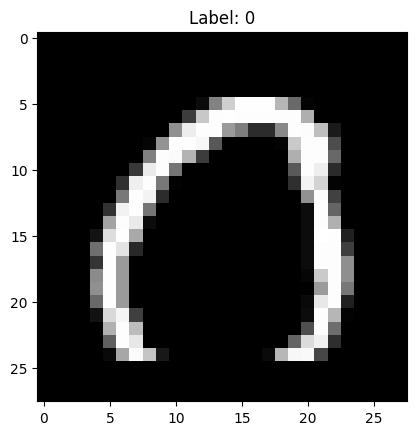

예측 확률: [[0.953 0.    0.017 0.001 0.    0.001 0.    0.001 0.002 0.025]]
예측 숫자: 0
실제 숫자: 0


In [ ]:
# 실제 숫자 이미지 하나 예측해보기

idx = 3412


sample = x_test[idx].reshape(1, 784)

_, _, _, pred = forward(sample, w1, b1, w2, b2)

#이미지 확인하기
plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y_test[idx]}")
plt.show()


print("예측 확률:", np.round(pred, 3))
print("예측 숫자:", np.argmax(pred))
print("실제 숫자:", y_test[idx])

In [ ]:
# 직접 쓴 숫자로 테스트하기

In [ ]:
# 그림판 코드

from google.colab import output
from IPython.display import HTML, display
import base64

def save_canvas_image(data):
    image_data = data.split(",")[1]
    image_bytes = base64.b64decode(image_data)

    with open("/content/my_number.png", "wb") as f:
        f.write(image_bytes)

    print("저장 완료: /content/my_number.png")

output.register_callback("notebook.save_canvas_image", save_canvas_image)

display(HTML("""
<canvas id="canvas" width="280" height="280"
style="border:2px solid black; background:black; touch-action:none;"></canvas>
<br>
<button onclick="clearCanvas()">Clear</button>
<button onclick="saveImage()">Save</button>

<script>
const canvas = document.getElementById("canvas");
const ctx = canvas.getContext("2d");

ctx.fillStyle = "black";
ctx.fillRect(0, 0, canvas.width, canvas.height);

ctx.strokeStyle = "white";
ctx.lineWidth = 18;
ctx.lineCap = "round";
ctx.lineJoin = "round";

let drawing = false;

function getPos(e) {
    const rect = canvas.getBoundingClientRect();

    if (e.touches) {
        return {
            x: e.touches[0].clientX - rect.left,
            y: e.touches[0].clientY - rect.top
        };
    } else {
        return {
            x: e.clientX - rect.left,
            y: e.clientY - rect.top
        };
    }
}

function startDraw(e) {
    drawing = true;
    const pos = getPos(e);
    ctx.beginPath();
    ctx.moveTo(pos.x, pos.y);
    e.preventDefault();
}

function draw(e) {
    if (!drawing) return;
    const pos = getPos(e);
    ctx.lineTo(pos.x, pos.y);
    ctx.stroke();
    e.preventDefault();
}

function endDraw(e) {
    drawing = false;
    e.preventDefault();
}

canvas.addEventListener("mousedown", startDraw);
canvas.addEventListener("mousemove", draw);
canvas.addEventListener("mouseup", endDraw);
canvas.addEventListener("mouseleave", endDraw);

canvas.addEventListener("touchstart", startDraw);
canvas.addEventListener("touchmove", draw);
canvas.addEventListener("touchend", endDraw);

function clearCanvas() {
    ctx.fillStyle = "black";
    ctx.fillRect(0, 0, canvas.width, canvas.height);
}

function saveImage() {
    const data = canvas.toDataURL("image/png");
    google.colab.kernel.invokeFunction("notebook.save_canvas_image", [data], {});
}
</script>
"""))

저장 완료: /content/my_number.png
저장 완료: /content/my_number.png
저장 완료: /content/my_number.png
저장 완료: /content/my_number.png
저장 완료: /content/my_number.png
저장 완료: /content/my_number.png
저장 완료: /content/my_number.png
저장 완료: /content/my_number.png
저장 완료: /content/my_number.png
저장 완료: /content/my_number.png
저장 완료: /content/my_number.png


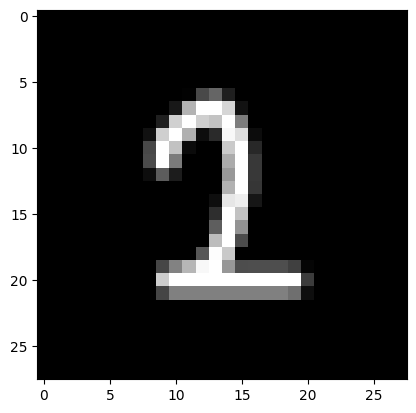

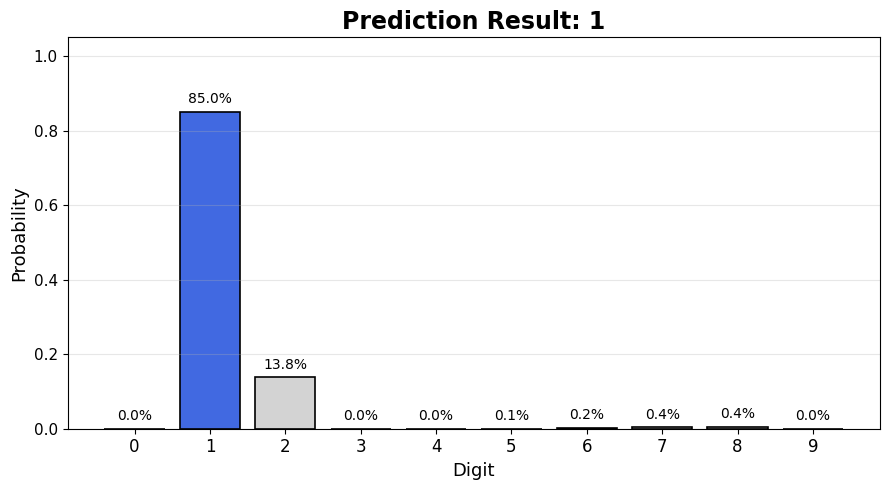

예측 숫자: 1


In [ ]:
# 결과 확인하기
from PIL import Image


img = Image.open("/content/my_number.png").convert("L")
img = img.resize((28, 28))

img_array = np.array(img) / 255.0

plt.imshow(img_array, cmap="gray")

img_input = img_array.reshape(1, 784)

_, _, _, pred = forward(img_input, w1, b1, w2, b2)

plt.imshow(img_array, cmap='gray')
plt.show()

plot_prediction(pred)
print("예측 숫자:", np.argmax(pred))

In [ ]:
# 7의 mnist 데이터 확인하기
# 7이 스타일 차이에 따른 차이가 유의미하다고 판단했기 때문에

# MNIST train 데이터 중 label이 7인 것만 찾기
seven_indices = np.where(y_train == 7)[0]

# 그중 100개 랜덤 선택
sample_indices = np.random.choice(seven_indices, 100, replace=False)

plt.figure(figsize=(10, 10))

for i, idx in enumerate(sample_indices):
    plt.subplot(10, 10, i + 1)
    plt.imshow(x_train[idx].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Random 100 samples of digit 7 from MNIST")
plt.show()